In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from george import kernels
import george
import scipy.optimize as op
import os, sys
other_folder_path = os.path.abspath('./../')
# Add the directory to sys.path
if other_folder_path not in sys.path:
    sys.path.append(other_folder_path)
from functions import *
from gp_model_params import info
from pathlib import Path
from glob import glob

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))


In [2]:
# Define home directory
home = str(Path.home())

In [3]:
def der(xy):
    """
    Compute the numerical derivative of a function given y-values and their corresponding x-values.

    Parameters
    ----------
    xy : array-like, shape (2, N)
        A two-element list or array where:
        - xy[0] contains the y-values,
        - xy[1] contains the corresponding x-values.

    Returns
    -------
    ndarray, shape (2, N-1)
        A two-row array:
        - Row 0: dy/dx (the finite difference derivative),
        - Row 1: midpoints of x (used as the new x positions of the derivative).
    """
    xder, yder = xy[1], xy[0]
    return np.array([np.diff(yder) / np.diff(xder), xder[:-1] + np.diff(xder) * 0.5])


def smoothness_gen(x, y, gp):
    """
    Generate a smoothness penalty term from a GP-predicted function.

    This function applies a second derivative estimate to a Gaussian Process (GP)
    prediction of y-values at positions x, and computes a scalar penalty measuring
    the total curvature or roughness of the prediction.

    Parameters
    ----------
    x : ndarray
        Input x-values.
    y : ndarray
        Observed y-values.
    gp : george.GP
        A Gaussian Process object from the `george` package.

    Returns
    -------
    float
        The total smoothness penalty, computed as the sum of the absolute
        second derivative values of the GP-predicted curve.
    """
    return np.nansum(np.abs(der(der([gp.predict(y, x)[0], x]))), axis=1)[0]
    
def nll(p, y, x, gp, s):
    """
    Compute the negative log-likelihood (NLL) with a smoothness regularization term.

    The function sets the GP kernel parameters, evaluates the likelihood of the
    data under the GP model, and penalizes non-smooth predictions using a tunable
    power-law penalty on second derivatives.

    Parameters
    ----------
    p : ndarray
        The kernel hyperparameter vector to set in the GP.
    y : ndarray
        The observed data values.
    x : ndarray
        The x-values corresponding to `y`.
    gp : george.GP
        A Gaussian Process object from the `george` package.
    s : float
        Smoothness exponent; larger values increase the penalty on rough solutions.

    Returns
    -------
    float
        The negative log-likelihood, regularized by the smoothness term.
        Returns a large penalty (1e25) if numerical instability or NaN is encountered.
    """
    gp.kernel.parameter_vector = p

    try:
        smoothness = smoothness_gen(x, y, gp)
        smoothness = smoothness if np.isfinite(smoothness) \
                                   and ~np.isnan(smoothness) else 1e25
    except np.linalg.LinAlgError:
        smoothness = 1e25

    ll = gp.log_likelihood(y, quiet=True)  # - (smoothness) #np.sum((y - pred[inds]**2)) #
    ll -= smoothness ** s

    # print('smoothness is ', smoothness)

    # print (p, -ll if np.isfinite(ll) else 1e25)
    return -ll if np.isfinite(ll) else 1e25

In [33]:
tp = 'CV_mine'
file_format = '.dat'
id_ = '0002'

In [35]:
# Set directory paths and read period data
direc = home+'/Research_data/Bulge_Variables/%s/phot/'%tp
direc_list = np.sort(glob(direc+'*'+file_format))
if not tp == 'CV_mine':
    list_periods = np.genfromtxt(home+'/Research_data/Bulge_Variables/%s/BLG_%s_OGLE_periods.txt'%(tp,tp), dtype='str')
    n_phs_original = info[tp]['n_phs']

In [36]:
direc_list

array(['/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-BLG-DN-0001.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-BLG-DN-0002.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-BLG-DN-0003.dat',
       ...,
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-MC-DN-0030.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-MC-DN-0031.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-MC-DN-0032.dat'],
      shape=(1091,), dtype='<U78')

In [37]:
# Reading an example light curve of a CV
path0 = direc_list[0]
t, m, merr = np.loadtxt(path0, unpack=True)

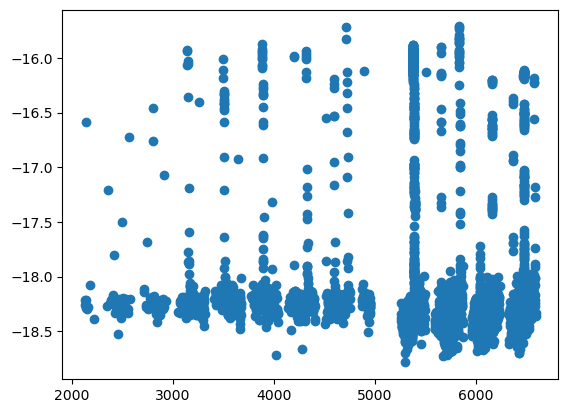

In [38]:
plt.scatter(t, -m)
# plt.xlim(-1,2000)

In [49]:
df_modified = prep_for_fit(df, np.nan, info['CV'])

NameError: name 'df' is not defined

In [48]:
gp = prep_gp(info['CV'], period=np.nan)
# x, y, e are either the full lc or an intrval of n phases of them conducted by repeating a folded phase n times
x, y, e = prep_input(df_modified, tp, period, info['CV'], Roman_max_short_time)

NameError: name 'df_modified' is not defined

In [39]:
# Defining the GP kernel
kernel = kernels.Product(kernels.ConstantKernel(1.10), kernels.Matern32Kernel(5.0))
#kernels.Product(kernels.ConstantKernel(1.10), kernels.ExpSquaredKernel(1.73))
gp = george.GP(kernel)

In [40]:
# Isolating a single peak in the light curve
t0 = 3500
ind_fit = ((t - t0)<2000) & ((t - t0)>0)
t_fit = (t- t0)[ind_fit]
m_fit = m[ind_fit]
err_fit = merr[ind_fit]
# res_fit = residuals[ind_fit]

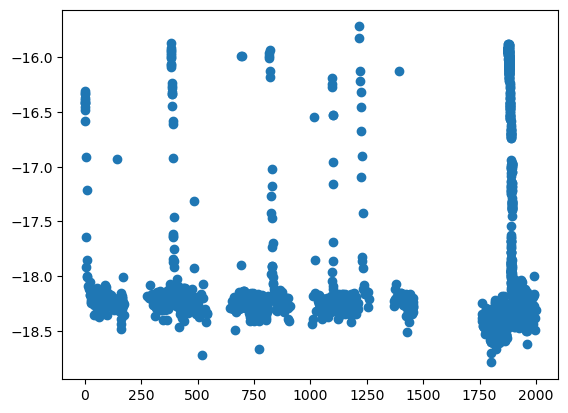

In [41]:
plt.scatter(t_fit, -m_fit)
# plt.xlim(-1,2000)

In [42]:
x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(t_fit, 
                                                                  m_fit, 
                                                                  err_fit,
                                                                  info['CV'],
                                                                  n_bins=1500)

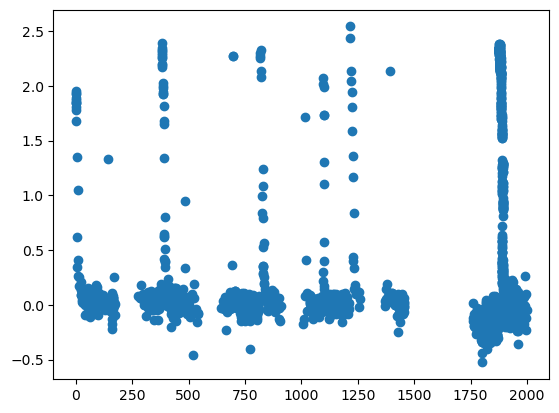

In [43]:
plt.scatter(x_binned, -1*y_binned)

In [24]:
x_binned = x_binned[~np.isnan(e_binned)]
y_binned = y_binned[~np.isnan(e_binned)]
e_binned = e_binned[~np.isnan(e_binned)]
x_binned = x_binned[~np.isinf(e_binned)]
y_binned = y_binned[~np.isinf(e_binned)]
e_binned = e_binned[~np.isinf(e_binned)]

In [28]:
gp = fit_gp(x_binned, y_binned, e_binned, info['CV'], gp)

ValueError: array must not contain infs or NaNs

In [25]:
# Optimizing parameters of the GP
# s determines the smoothness of the fit, larger s= smoother curve
gp.compute(x_binned, e_binned)
p0 = gp.kernel.parameter_vector
s = 2
results = op.minimize(nll, [p0[0], p0[1]],
                      args=(y_binned-np.median(y_binned),
                            x_binned, gp, s))
# Update the kernel and print the final log-likelihood.
gp.kernel.parameter_vector = results.x

ValueError: array must not contain infs or NaNs

In [ ]:
# Predicting on a new time sampling

t_fit_new = np.linspace(0,2000, 2000)
model_interp_new = model_interp(t_fit_new)
mu, cov = gp.predict(y_binned-np.median(y_binned), t_fit_new)
std = np.sqrt(np.diag(cov))

In [ ]:
gp.kernel.parameter_vector

Text(0, 0.5, 'Magnitude')

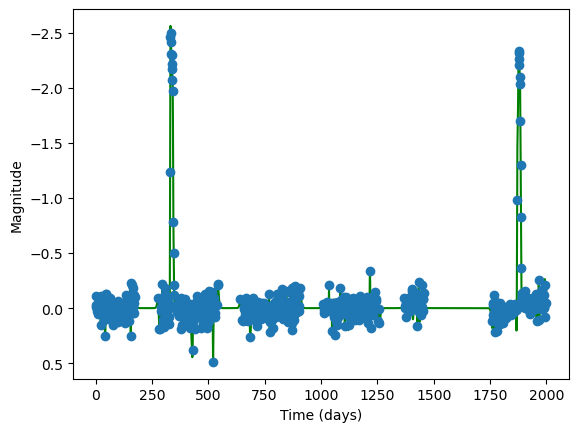

In [85]:
plt.errorbar(x_binned, y_binned-np.median(y_binned), yerr=e_binned, fmt='o', label='Data')
plt.plot(t_fit_new, mu, color='g', label='GP fit')

plt.gca().invert_yaxis()

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
# plt.xlim(1000,1100)